# Quantify failure of an IVP
When no solution to an ODE system exists, quantify the failure some other way.

In [177]:
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

## Test different stabilities makes sense

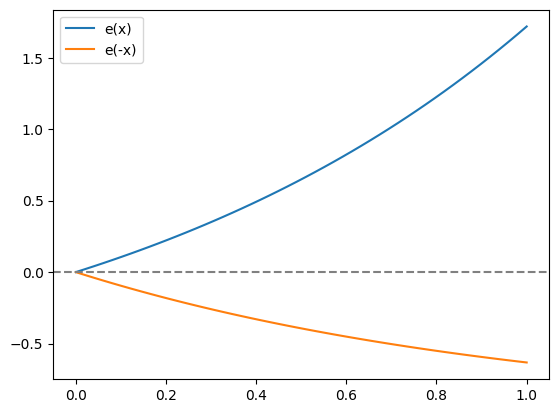

In [178]:
# Test
x = np.linspace(0, 1, 50)
y1 = np.exp(x) - 1
y2 = np.exp(-x) - 1
fig, ax = plt.subplots()
ax.plot(x, y1, label="e(x)")
ax.plot(x, y2, label="e(-x)")
ax.axhline(y=0.0, linestyle="--", color="grey")
ax.legend()

Explain difference in stability between x,y and -x,y directions.

In [179]:
# Solution points
xys = np.array([[0.2, 0.8], [0.8, 0.2]])
# x,y and -x,y finite diffs
dxys = np.array([[0.1, 0.1], [-0.1, -0.1], [0.1, -0.1], [-0.1, 0.1]])
for xy in xys:
    print(f"{xy = }")
    for dxy in dxys:
        dx_dt = np.exp(-(xy[0] + dxy[0])) + np.exp(-(xy[1] + dxy[1])) - 1.3
        dy_dt = -np.exp(xy[0] + dxy[0]) - np.exp(xy[1] + dxy[1]) + 3.5
        print(f"{dxy = }")
        print(f"{dx_dt.item() = :.3e}")
        print(f"{dy_dt.item() = :.3e}")

xy = array([0.2, 0.8])
dxy = array([0.1, 0.1])
dx_dt.item() = -1.526e-01
dy_dt.item() = -3.095e-01
dxy = array([-0.1, -0.1])
dx_dt.item() = 1.014e-01
dy_dt.item() = 3.811e-01
dxy = array([ 0.1, -0.1])
dx_dt.item() = -6.260e-02
dy_dt.item() = 1.364e-01
dxy = array([-0.1,  0.1])
dx_dt.item() = 1.141e-02
dy_dt.item() = -6.477e-02
xy = array([0.8, 0.2])
dxy = array([0.1, 0.1])
dx_dt.item() = -1.526e-01
dy_dt.item() = -3.095e-01
dxy = array([-0.1, -0.1])
dx_dt.item() = 1.014e-01
dy_dt.item() = 3.811e-01
dxy = array([ 0.1, -0.1])
dx_dt.item() = 1.141e-02
dy_dt.item() = -6.477e-02
dxy = array([-0.1,  0.1])
dx_dt.item() = -6.260e-02
dy_dt.item() = 1.364e-01


Shows that high x, low y solution is indeed unstable.

## Plot toy 2 ODE system

Define 2 ODE system and plot equilibria.

Text(0.5, 1.0, 'Vector field')

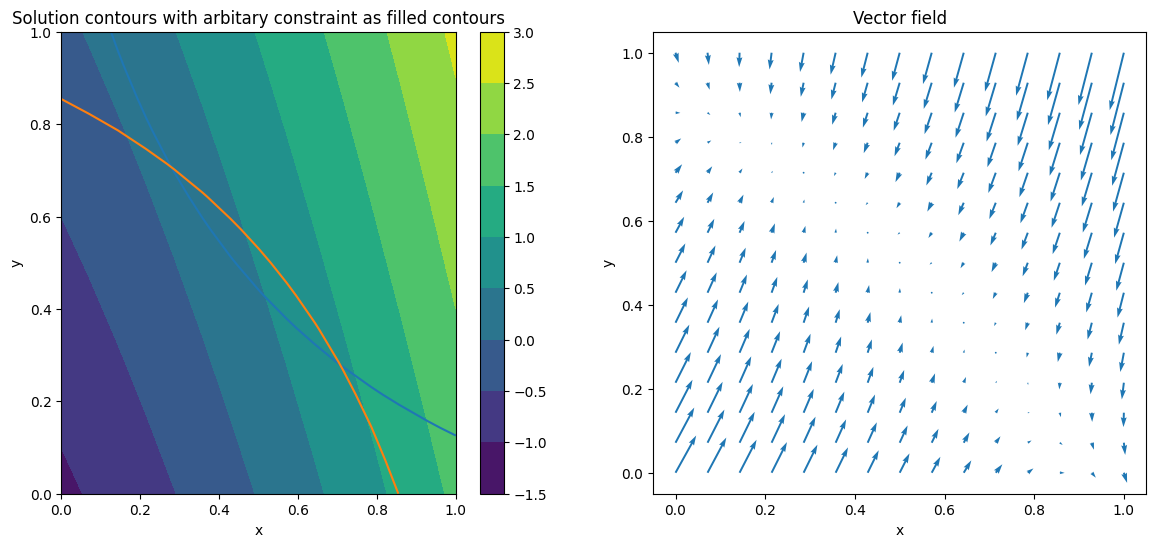

In [180]:
def evaluate(x, y):
    # Want one stable, one unstable solution
    dx_dt = np.exp(-x) + np.exp(-y) - 1.25
    dy_dt = -np.exp(x) - np.exp(y) + 3.35
    return dx_dt, dy_dt


def constraint(x, y):
    return 0.9 * (1 + x) ** 2 + y - 2.0


def evaluate_with_con(x, y):
    dx_dt, dy_dt = evaluate(x, y)
    con = constraint(x, y)

    return dx_dt, dy_dt, con


N = 15
x = np.linspace(0, 1, num=N)
y = np.linspace(0, 1, num=N)
x_grid, y_grid = np.meshgrid(x, y)
evaluate_vec = np.vectorize(evaluate_with_con)
dx_dt_grid, dy_dt_grid, con_grid = evaluate_vec(x_grid, y_grid)
fig, ax = plt.subplots(ncols=2)
fig.set_size_inches(14, 6)
ax[0].contour(x_grid, y_grid, dx_dt_grid, levels=[0.0], colors="C0")
ax[0].contour(x_grid, y_grid, dy_dt_grid, levels=[0.0], colors="C1")
cs = ax[0].contourf(x_grid, y_grid, con_grid)
fig.colorbar(cs)
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_title("Solution contours with arbitary constraint as filled contours")

ax[1].quiver(x_grid, y_grid, dx_dt_grid, dy_dt_grid, color="C0")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_title("Vector field")
# dx_dt_grid
# dy_dt_grid

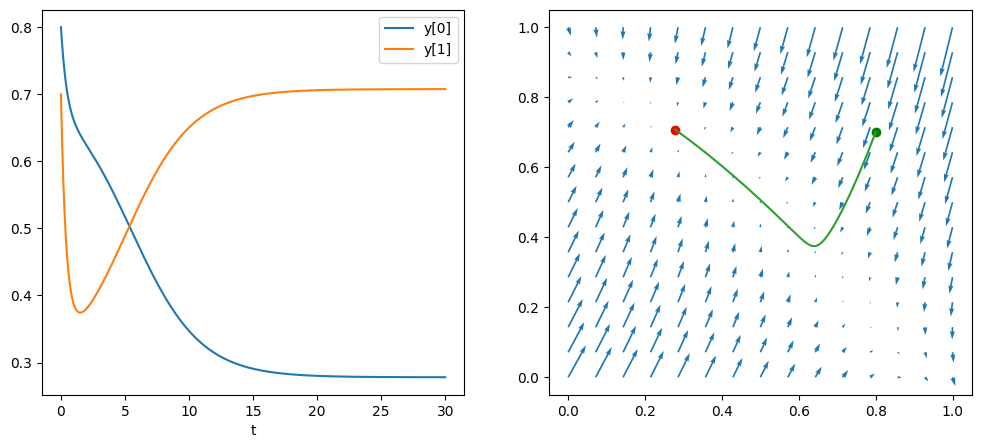

In [181]:
def ivp_evaluate(t, y_vec):
    x = y_vec[0]
    y = y_vec[1]
    return evaluate(x, y)


time_span = [0, 30]
initial_values = [0.8, 0.7]
sol = solve_ivp(
    fun=ivp_evaluate,
    t_span=time_span,
    y0=initial_values,
    dense_output=True,
    max_step=0.1,
)
# Plot
fig, ax = plt.subplots(ncols=2)
fig.set_size_inches(12, 5)
for i in range(len(initial_values)):
    ax[0].plot(sol.t, sol.y[i, :], label=f"y[{i}]")

ax[0].legend()
ax[0].set_xlabel("t")

ax[1].quiver(x_grid, y_grid, dx_dt_grid, dy_dt_grid, color="C0")
# Plot over vector field
# Initial point
ax[1].scatter(sol.y[0, 0], sol.y[1, 0], color="g")
ax[1].plot(sol.y[0, :], sol.y[1, :], color="C2")
ax[1].scatter(sol.y[0, -1], sol.y[1, -1], color="r")

## Different equilibria
Move solution location, simulating an uncertain parameter, and record constraint violations.

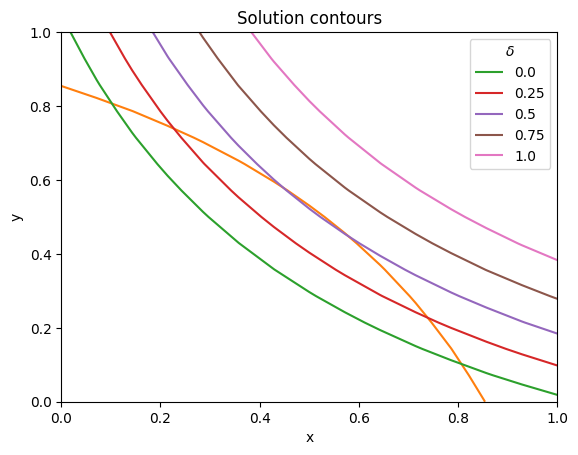

In [182]:
def evaluate_with_unc_param(x, y, unc_param):
    # Want one stable, one unstable solution
    dx_dt = np.exp(-x) + np.exp(-y) - 1.35 + 0.3 * unc_param
    dy_dt = -np.exp(x) - np.exp(y) + 3.35
    con = constraint(x, y)

    return dx_dt, dy_dt, con


evaluate_vec = np.vectorize(evaluate_with_unc_param)
# Uncertain param values
unc_param = np.linspace(0.0, 1.0, num=5)
dx_dt_grid, dy_dt_grid, con_grid = evaluate_vec(
    x_grid[:, :, np.newaxis], y_grid[:, :, np.newaxis], unc_param
)
fig, ax = plt.subplots()
contours = []
for i, value in enumerate(unc_param):
    if i == 0:
        # Same for all: only plot once
        ax.contour(x_grid, y_grid, dy_dt_grid[:, :, i], levels=[0.0], colors="C1")
    contours.append(
        ax.contour(
            x_grid,
            y_grid,
            dx_dt_grid[:, :, i],
            levels=[0.0],
            colors=f"C{i + 2}",
        )
    )
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Solution contours")

# TODO Sort legend
names = []
labels = []
for contour in contours:
    name, label = contour.legend_elements()
    names.append(name[0])
    labels.append(label[0])
labels = unc_param
ax.legend(names, labels, title="$\delta$")

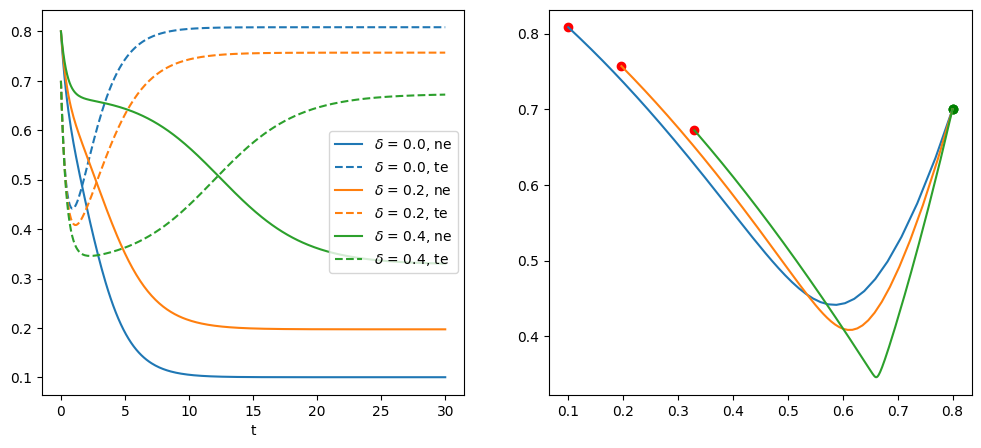

In [183]:
def ivp_evaluate(t, y_vec, unc_param):
    x = y_vec[0]
    y = y_vec[1]
    dx_dt, dy_dt, _ = evaluate_with_unc_param(x, y, unc_param)
    return dx_dt, dy_dt


time_span = [0, 30]
initial_values = [0.8, 0.7]
sols = []
# Values chosen to always have solutions at this stage
unc_param = np.array([0.0, 0.2, 0.4])
for unc_param_i in unc_param:
    sols.append(
        solve_ivp(
            fun=ivp_evaluate,
            t_span=time_span,
            y0=initial_values,
            dense_output=True,
            max_step=0.1,
            args=(unc_param_i,),
        )
    )

# Plot
fig, ax = plt.subplots(ncols=2)
fig.set_size_inches(12, 5)
for i, sol in enumerate(sols):
    ax[0].plot(
        sol.t, sol.y[0, :], label=f"$\delta$ = {unc_param[i]}, ne", c=f"C{str(i)}"
    )
    ax[0].plot(
        sol.t,
        sol.y[1, :],
        label=f"$\delta$ = {unc_param[i]}, te",
        c=f"C{str(i)}",
        linestyle="--",
    )

ax[0].legend()
ax[0].set_xlabel("t")

# Plot over vector field
# Initial point
for i, sol in enumerate(sols):
    ax[1].scatter(sol.y[0, 0], sol.y[1, 0], color="g")
    ax[1].plot(sol.y[0, :], sol.y[1, :], color=f"C{str(i)}")
    ax[1].scatter(sol.y[0, -1], sol.y[1, -1], color="r")

## Cause a single failure and minimise it
Set an uncertain parameter so high so that no stable solution exists, then attempt to find how far away from a solution it is.

Text(0.5, 1.0, 'Vector field')

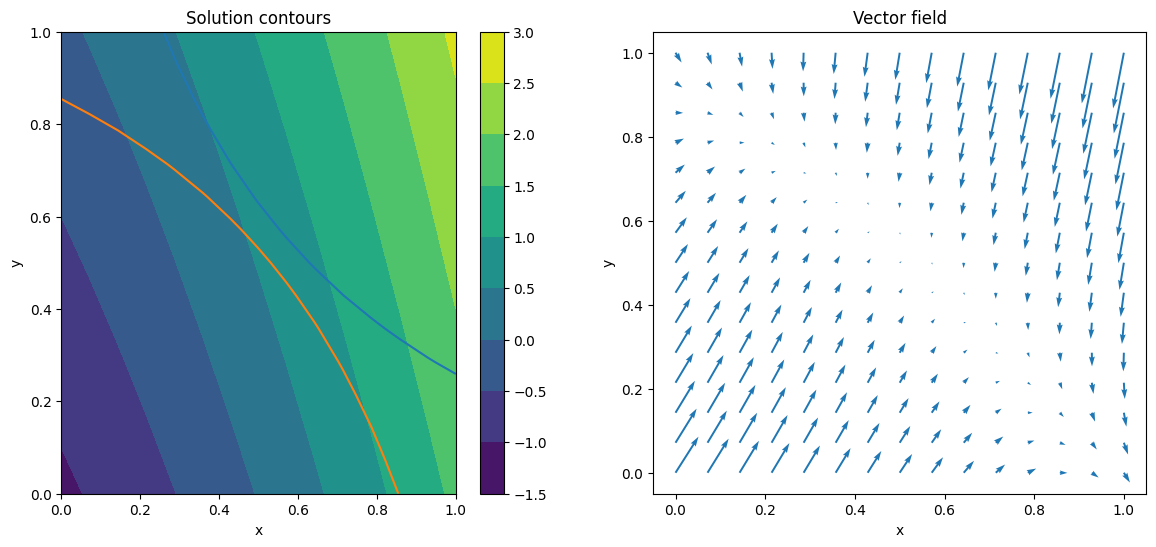

In [184]:
unc_param = 0.7
N = 15
x = np.linspace(0, 1, num=N)
y = np.linspace(0, 1, num=N)
x_grid, y_grid = np.meshgrid(x, y)
evaluate_vec = np.vectorize(evaluate_with_unc_param)
dx_dt_grid, dy_dt_grid, con_grid = evaluate_vec(x_grid, y_grid, unc_param)
fig, ax = plt.subplots(ncols=2)
fig.set_size_inches(14, 6)
ax[0].contour(x_grid, y_grid, dx_dt_grid, levels=[0.0], colors="C0")
ax[0].contour(x_grid, y_grid, dy_dt_grid, levels=[0.0], colors="C1")
cs = ax[0].contourf(x_grid, y_grid, con_grid)
fig.colorbar(cs)
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_title("Solution contours")

ax[1].quiver(x_grid, y_grid, dx_dt_grid, dy_dt_grid, color="C0")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_title("Vector field")

No solution exists now. Plot IVP result:

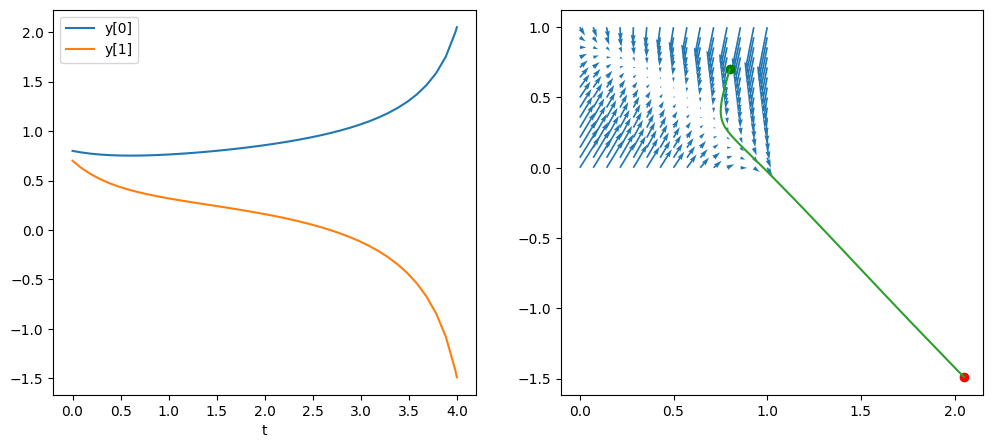

In [185]:
time_span = [0, 4]
sol = solve_ivp(
    fun=ivp_evaluate,
    t_span=time_span,
    y0=initial_values,
    dense_output=True,
    max_step=0.1,
    args=(unc_param,),
)

# Plot
fig, ax = plt.subplots(ncols=2)
fig.set_size_inches(12, 5)
for i in range(len(initial_values)):
    ax[0].plot(sol.t, sol.y[i, :], label=f"y[{i}]")

ax[0].legend()
ax[0].set_xlabel("t")

ax[1].quiver(x_grid, y_grid, dx_dt_grid, dy_dt_grid, color="C0")
# Plot over vector field
# Initial point
ax[1].scatter(sol.y[0, 0], sol.y[1, 0], color="g")
ax[1].plot(sol.y[0, :], sol.y[1, :], color="C2")
ax[1].scatter(sol.y[0, -1], sol.y[1, -1], color="r")

The solution is diverging.

Cause an error if not converged after time interval, then in this case run an optimisation to minimise residual.

status = -1
Residual = 2.593e-03


/tmp/ipykernel_22560/2542967647.py:3: RuntimeWarning: overflow encountered in exp
  dx_dt = np.exp(-x) + np.exp(-y) - 1.35 + 0.3 * unc_param
/tmp/ipykernel_22560/2542967647.py:4: RuntimeWarning: overflow encountered in exp
  dy_dt = -np.exp(x) - np.exp(y) + 3.35
/tmp/ipykernel_22560/2802436932.py:9: RuntimeWarning: invalid value encountered in scalar add
  return 0.9 * (1 + x) ** 2 + y - 2.0
/home/jon/anaconda3/envs/notebooks/lib/python3.11/site-packages/scipy/integrate/_ivp/rk.py:106: RuntimeWarning: invalid value encountered in dot
  return np.dot(K.T, self.E) * h
/home/jon/anaconda3/envs/notebooks/lib/python3.11/site-packages/scipy/integrate/_ivp/rk.py:66: RuntimeWarning: invalid value encountered in dot
  y_new = y + h * np.dot(K[:-1].T, B)
/tmp/ipykernel_22560/2802436932.py:9: RuntimeWarning: overflow encountered in scalar power
  return 0.9 * (1 + x) ** 2 + y - 2.0
/home/jon/anaconda3/envs/notebooks/lib/python3.11/site-packages/scipy/integrate/_ivp/rk.py:63: RuntimeWarning: inval

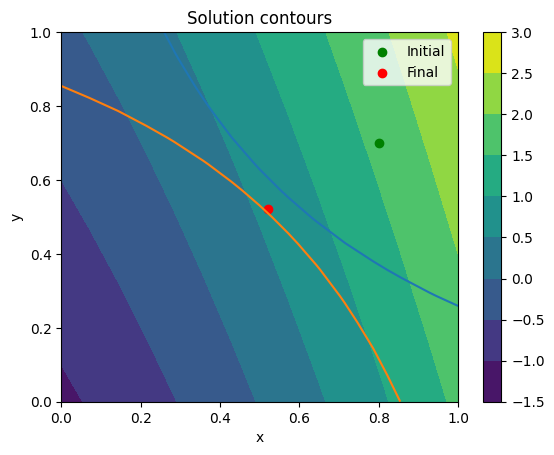

In [186]:
def detect_steady_state(t, y, unc_param):
    # Terminate integration when d/dts below tolerance (crosses 0)
    tol = 5.0e-3
    dx_dt, dy_dt = ivp_evaluate(t, y, unc_param)
    return np.sqrt(dx_dt**2 + dy_dt**2) - tol


def residual(x_vec, unc_param):
    dx_dt, dy_dt, con = evaluate_with_unc_param(x_vec[0], x_vec[1], unc_param)
    return dx_dt**2 + dy_dt**2


detect_steady_state.terminal = True

time_span = [0, 10]
unc_param = 0.7

sol = solve_ivp(
    fun=ivp_evaluate,
    t_span=time_span,
    y0=initial_values,
    dense_output=True,
    max_step=0.1,
    args=(unc_param,),
    events=detect_steady_state,
)
print(f"status = {sol.status}")
if sol.status in [-1, 0]:
    # 0: Reached end of time interval without converging
    # -1: Solver error
    # Run optimiser
    result = minimize(fun=residual, x0=initial_values, args=(unc_param))
    if result.success:
        res = result.fun
        print(f"Residual = {res:.3e}")

elif sol.status == 1:
    # 1: Termination event occurred
    raise Exception("Don't want an IVP solution!")


N = 15
x = np.linspace(0, 1, num=N)
y = np.linspace(0, 1, num=N)
x_grid, y_grid = np.meshgrid(x, y)
evaluate_vec = np.vectorize(evaluate_with_unc_param)
dx_dt_grid, dy_dt_grid, con_grid = evaluate_vec(x_grid, y_grid, unc_param)
fig, ax = plt.subplots()
ax.contour(x_grid, y_grid, dx_dt_grid, levels=[0.0], colors="C0")
ax.contour(x_grid, y_grid, dy_dt_grid, levels=[0.0], colors="C1")
cs = ax.contourf(x_grid, y_grid, con_grid)
fig.colorbar(cs)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Solution contours")
# print(result.x)
ax.scatter(initial_values[0], initial_values[1], c="g", label="Initial")
ax.scatter(result.x[0], result.x[1], c="r", label="Final")
ax.legend()


Now have a residual value when no solution is possible.

## Combine w (solved) and residuals (no solution)

/tmp/ipykernel_22560/2542967647.py:3: RuntimeWarning: overflow encountered in exp
  dx_dt = np.exp(-x) + np.exp(-y) - 1.35 + 0.3 * unc_param
/tmp/ipykernel_22560/2542967647.py:4: RuntimeWarning: overflow encountered in exp
  dy_dt = -np.exp(x) - np.exp(y) + 3.35
/tmp/ipykernel_22560/2802436932.py:9: RuntimeWarning: invalid value encountered in scalar add
  return 0.9 * (1 + x) ** 2 + y - 2.0
/tmp/ipykernel_22560/2802436932.py:9: RuntimeWarning: overflow encountered in scalar power
  return 0.9 * (1 + x) ** 2 + y - 2.0
/home/jon/anaconda3/envs/notebooks/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


Text(0.5, 1.0, 'Failure severity for converged solutions and unconverged residuals')

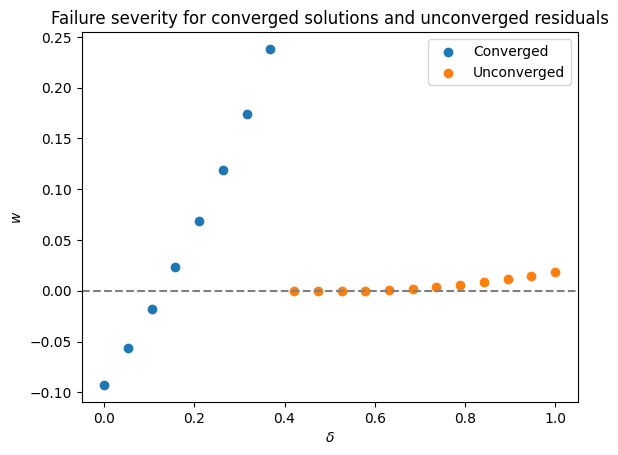

In [ ]:
unc_param = np.linspace(0.0, 1.0, num=20)
w = np.empty_like(unc_param)
ivp_status = np.empty_like(unc_param)
time_span = [0, 20]
for i, unc_param_i in enumerate(unc_param):
    sol = solve_ivp(
        fun=ivp_evaluate,
        t_span=time_span,
        y0=initial_values,
        dense_output=True,
        max_step=0.1,
        args=(unc_param_i,),
        events=detect_steady_state,
    )
    # print(f"status = {sol.status}")
    ivp_status[i] = sol.status
    if sol.status in [-1, 0]:
        # 0: Reached end of time interval without converging
        # -1: Solver error
        # Run optimiser
        result = minimize(fun=residual, x0=initial_values, args=(unc_param_i,))
        if result.success:
            res = result.fun
            w[i] = res
        else:
            raise Exception("Residual optimiser failed")

    elif sol.status == 1:
        # 1: Termination event occurred
        # Final constraint value
        _, _, con = evaluate_with_unc_param(
            x=sol.y[0, -1], y=sol.y[1, -1], unc_param=unc_param_i
        )
        w[i] = con

fig, ax = plt.subplots()
ax.axhline(0.0, linestyle="--", c="grey")
ax.scatter(unc_param[ivp_status > 0], w[ivp_status > 0], label="Converged")
ax.scatter(unc_param[ivp_status < 0], w[ivp_status < 0], label="Unconverged")
ax.set_xlabel("$\delta$")
ax.set_ylabel("$w$")
ax.legend()
ax.set_title("Failure severity for converged solutions and unconverged residuals")

Great, but requires adjusting to make sense: not converging should be a serious failure.

## Adjusting failure to converge


Text(0.5, 1.0, 'Failure severity for converged solutions and unconverged residuals')

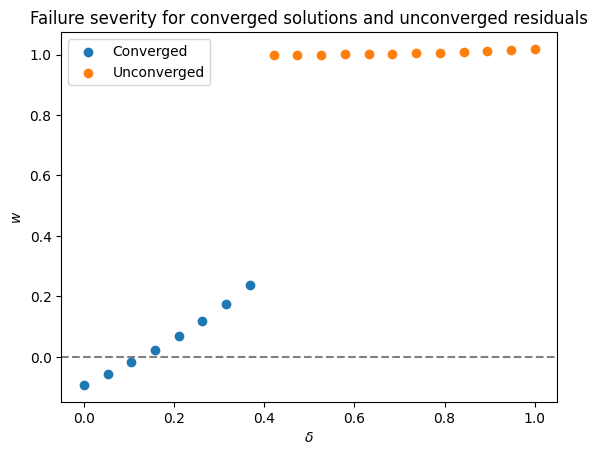

In [188]:
# Post-process
w_mod = np.copy(w)
w_mod[ivp_status < 0] += 1.0

fig, ax = plt.subplots()
ivp_status > 0
ax.axhline(0.0, linestyle="--", c="grey")
ax.scatter(unc_param[ivp_status > 0], w_mod[ivp_status > 0], label="Converged")
ax.scatter(unc_param[ivp_status < 0], w_mod[ivp_status < 0], label="Unconverged")
ax.set_xlabel("$\delta$")
ax.set_ylabel("$w$")
ax.legend()
ax.set_title("Failure severity for converged solutions and unconverged residuals")